    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

Confusion Matrix:
 [[65  3]
 [ 8 24]]

TP = 24
FP = 3
TN = 65
FN = 8

Accuracy = 0.89
Error Rate = 0.10999999999999999
Precision = 0.8888888888888888
Recall = 0.75


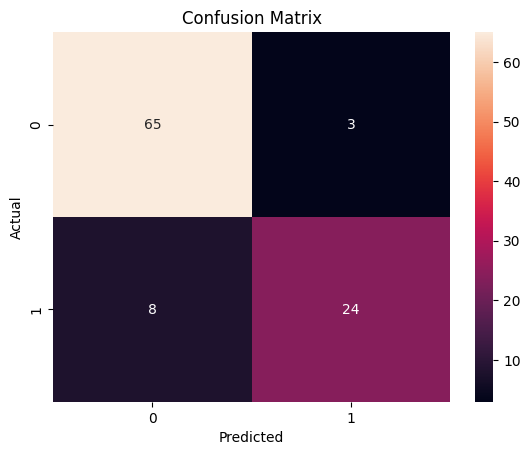

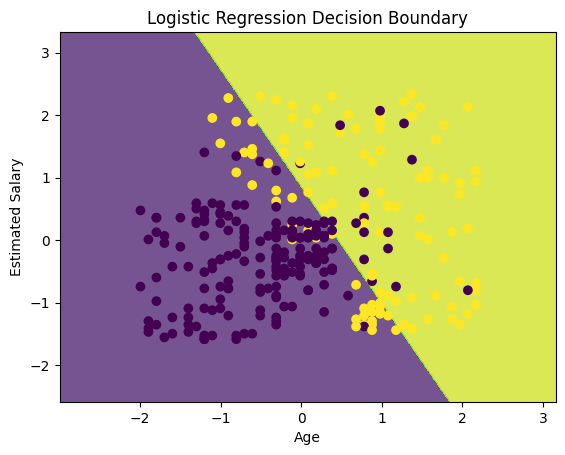

In [1]:
# =========================================================
# LOGISTIC REGRESSION - Social_Network_Ads.csv
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. LOAD DATASET
# =========================================================

df = pd.read_csv("Social_Network_Ads.csv")

print(df.head())

# =========================================================
# 2. DATA PREPROCESSING
# =========================================================

# Drop unnecessary columns
df = df.drop(['User ID', 'Gender'], axis=1)

# Features and target
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

# =========================================================
# 3. SPLIT DATA
# =========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# =========================================================
# 4. FEATURE SCALING
# =========================================================

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# =========================================================
# 5. TRAIN MODEL
# =========================================================

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

# =========================================================
# 6. PREDICTIONS
# =========================================================

y_pred = model.predict(X_test)

# =========================================================
# 7. CONFUSION MATRIX
# =========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

TN, FP, FN, TP = cm.ravel()

print("\nTP =", TP)
print("FP =", FP)
print("TN =", TN)
print("FN =", FN)

# =========================================================
# 8. PERFORMANCE METRICS
# =========================================================

accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("\nAccuracy =", accuracy)
print("Error Rate =", error_rate)
print("Precision =", precision)
print("Recall =", recall)

# =========================================================
# 9. CONFUSION MATRIX HEATMAP
# =========================================================

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================================
# 10. DECISION BOUNDARY
# =========================================================

from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min()-1, X_set[:, 0].max()+1, 0.01),
    np.arange(X_set[:, 1].min()-1, X_set[:, 1].max()+1, 0.01)
)

plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75
)

plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set)

plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.show()